#HW 8: Heap Sort

- Please disable code autocomplete by uncheck "Show context-powered code completions" in Tools -> Settings -> Editor.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import random

##Implement Heap Sort
- Please refer to Sections 10.3.1 and 10.5


In [2]:
# Heap Sort

def HeapSort(array, n):
    heap = [None] * n
    
    # heap under construction
    for i in range(n):
        Insert(array[i], heap, i)
        
    # ez sort
    sorted_arr = []
    for i in range(n):
        sorted_arr.append(ExtractMin(heap, n - i))
    
    return sorted_arr

def Insert(new_element, heap, num):
    heap[num] = new_element # place at bottom of heap
    
    parent_idx = (num - 1) // 2
    while num > 0: # bubble up
        parent_val = heap[parent_idx]
        if new_element < parent_val:
            heap[parent_idx] = new_element
            heap[num] = parent_val
            num = parent_idx
            parent_idx = (num - 1) // 2
            continue
        break

def ExtractMin(heap, num):
    ret = heap[0] # smallest
    heap[0] = heap[num - 1]
    num -= 1

    index = 0
    while True:
        left = 2 * index + 1
        right = 2 * index + 2

        smallest = index
        if left < num and heap[left] < heap[smallest]:
            smallest = left
        if right < num and heap[right] < heap[smallest]:
            smallest = right

        if smallest != index:
            heap[index], heap[smallest] = heap[smallest], heap[index] # swap!
            index = smallest
        else:
            break
    return ret

# Help function for testing
def IsSorted(array):
    for i in range(len(array)-1):
        if array[i] > array[i+1]:
            return False

    return True

In [3]:
# Quick test on some input arrays
testCases = [[1, 2, 3, 4, 5],
             [2, 1, 4, 3, 5],
             [3, 2, 1, 5, 4],
             [5, 4, 3, 2, 1],
             [3, 3, 5, 1, 2]]

print("Heap Sort:")
for testCase in testCases:
    print(testCase)
    result = HeapSort(testCase, len(testCase))
    print(result)
    print(IsSorted(result))


Heap Sort:
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[2, 1, 4, 3, 5]
[1, 2, 3, 4, 5]
True
[3, 2, 1, 5, 4]
[1, 2, 3, 4, 5]
True
[5, 4, 3, 2, 1]
[1, 2, 3, 4, 5]
True
[3, 3, 5, 1, 2]
[1, 2, 3, 3, 5]
True


##Compare HeapSort with MergeSort

In [4]:
# Implement MergeSort

# Implement Merge Sort
# Refer to Merge Sort described in Chapter 1.4 in Textbook

def MergeSort(array):
    if len(array) <= 1:
        return array
    else:
        left = MergeSort(array[:len(array)//2])
        right = MergeSort(array[len(array)//2:])
        return Merge(left, right)

def Merge(left, right):
    result = []
    i = 0
    j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result


In [5]:
# Quick test on some input arrays for MergeSort
testCases = [[1, 2, 3, 4, 5],
             [2, 1, 4, 3, 5],
             [3, 2, 1, 5, 4],
             [5, 4, 3, 2, 1],
             [3, 3, 5, 1, 2]]

for testCase in testCases:
    print(testCase)
    output = MergeSort(testCase)
    print(output)
    print(IsSorted(output))

[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[2, 1, 4, 3, 5]
[1, 2, 3, 4, 5]
True
[3, 2, 1, 5, 4]
[1, 2, 3, 4, 5]
True
[5, 4, 3, 2, 1]
[1, 2, 3, 4, 5]
True
[3, 3, 5, 1, 2]
[1, 2, 3, 3, 5]
True


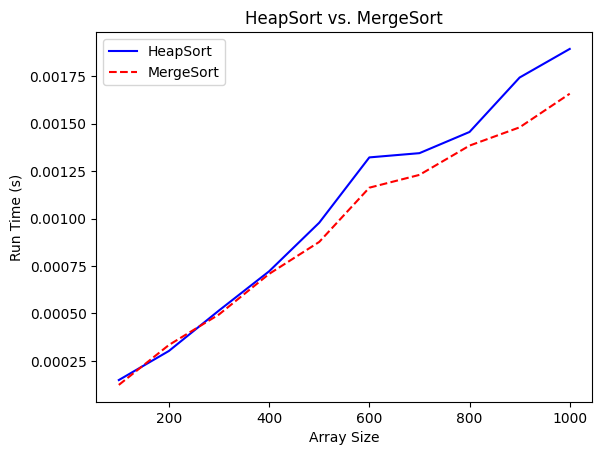

In [6]:
maxNumber = 20000
startArraySize = 100
endArraySize = 1000
stepArraySize = 100
runsPerSize = 1000

# Generate a random array of a given size
def GenerateRandomArray(size):
    return np.random.randint(0, maxNumber, size)

averageRunTimesHeapSort = []
averageRunTimesMergeSort = []

np.random.seed(42)

for arraySize in range(startArraySize, endArraySize+1, stepArraySize):
    runTimesHeapSort = []
    runTimesMergeSort = []

    for run in range(runsPerSize):
        array = GenerateRandomArray(arraySize)
        backup_array_1 = array.copy()
        backup_array_2 = array.copy()

        start = time.time()
        resultMergeSort = MergeSort(backup_array_1)
        end = time.time()
        runTimesMergeSort.append(end-start)

        start = time.time()
        resultHeapSort = HeapSort(backup_array_2, len(backup_array_2))
        end = time.time()
        runTimesHeapSort.append(end-start)

        if not IsSorted(resultHeapSort):
            print("Error: HeapSort not correct")
            print("Original Array: ", array)
            print("HeapSort: ", resultHeapSort)
            print("MergeSort: ", resultMergeSort)
            break

    averageRunTimesHeapSort.append(np.mean(runTimesHeapSort))
    averageRunTimesMergeSort.append(np.mean(runTimesMergeSort))

x = np.arange(startArraySize, endArraySize+1, stepArraySize)
plt.plot(x, averageRunTimesHeapSort, 'b', label='HeapSort')
plt.plot(x, averageRunTimesMergeSort, 'r--', label='MergeSort')
plt.title('HeapSort vs. MergeSort')
plt.xlabel('Array Size')
plt.ylabel('Run Time (s)')
plt.legend()
plt.show()
